# U.S. Equity Market Regimes — Gaussian Mixture Model (point-in-time)

Classify the U.S. market environment into latent regimes with a **Gaussian Mixture Model (GMM)** fed by
cross-asset data (equity, volatility, credit, rates, inflation expectations, gold) plus the
historical performance of the **S&P 500 Total Return index (SPXTR)**, then study

1. the **economic profile** of each regime (mean and S.D. of every variable), and
2. the **forward return of SPXTR** conditional on the regime.

**Point-in-time design (no look-ahead)**

| Risk of look-ahead | How it is handled |
|---|---|
| Publication lag of ICE BofA / FRED series (OAS, corporate yields, TIPS, breakevens) | Shifted by **1 trading day** before use |
| Feature construction | Trailing windows only (returns, vol, drawdown, changes, de-trending) |
| Scaling / PCA / GMM fitted on the full sample | **Walk-forward**: expanding window, re-fit every quarter, only data available at the re-fit date |
| Label switching between re-fits | Each new fit is aligned to the previous one (Hungarian matching on the training data) — never to a future model |
| Choice of K | Driven by **walk-forward out-of-sample log-likelihood** + stability + economic constraints — forward returns are **never** used |
| Forward returns | Used only for evaluation, measured from the close of the classification week |

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Patch
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

ROOT = Path('../')
DATA_DIR = ROOT / 'data/tradingview/us_regime'

# ---- model settings ----
SEED = 42
N_PCS = 6              # PCA components fed to the GMM (~77% of variance)
COV_TYPE = 'full'
REG_COVAR = 1e-3
N_INIT = 10
K_RANGE = range(1, 9)
INIT_WEEKS = 156       # first training window (3 years) before the first out-of-sample label
REFIT_EVERY = 13       # re-fit the model every quarter (13 weeks)
OOS_FOLD = 52          # out-of-sample fold length for K selection (1 year)
MIN_SHARE = 0.05       # economic constraint: every regime >= 5% of weeks
MIN_DURATION = 4       # economic constraint: average spell >= 4 weeks (~1 month)
HORIZONS = {'1m': 4, '3m': 13, '6m': 26, '12m': 52}   # forward horizons in weeks

# ---- chart style (recessive chrome, thin marks) ----
INK, INK_2, MUTED, GRID, AXIS, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7', '#fcfcfb'
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
DIVERGING = LinearSegmentedColormap.from_list('div', ['#184f95', '#6da7ec', '#f0efec', '#ec8d8c', '#b3302f'])
SEQUENTIAL = LinearSegmentedColormap.from_list('seq', ['#f0efec', '#9ec5f4', '#3987e5', '#184f95'])
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'font.family': 'sans-serif', 'font.size': 9.5,
    'text.color': INK, 'axes.labelcolor': INK_2, 'axes.titlecolor': INK, 'axes.titlesize': 11,
    'axes.titleweight': 'semibold', 'axes.titlelocation': 'left',
    'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.edgecolor': AXIS,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 2, 'legend.frameon': False, 'axes.axisbelow': True,
})

## 1. Load data

Daily TradingView export. `close` is **SPXTR**; the remaining columns are cross-asset series.

In [2]:
RENAME = {
    'close': 'spxtr',
    'Cboe 20+ Year Treasury Bond ETF Volatility Basis Point Index · CBOE: close': 'tlt_vol_bp',
    'Cboe S&P 500 Constituent Volatility Index · CBOE: close': 'vixeq',
    'Cboe 1-Month Implied Correlation Index · CBOE: close': 'impl_corr',
    'PUT/CALL RATIO (EQUITIES) - CBOE · USI: close': 'put_call',
    'ICE BofA CCC & Lower US High Yield Index Option-Adjusted Spread · ICE: close': 'ccc_oas',
    'West Texas Intermediate Crude Oil cash · BlackBull Markets: close': 'wti',
    'CFDs on Gold (US$ / OZ) · TVC: close': 'gold',
    'ICE BofA AAA US Corporate Index Option-Adjusted Spread · ICE: close': 'aaa_oas',
    'ICE BofA 7-10 Year US Corporate Index Effective Yield · ICE: close': 'corp_7_10y',
    'ICE BofA 1-3 Year US Corporate Index Effective Yield · ICE: close': 'corp_1_3y',
    'ICE BofA US Corporate Index Option-Adjusted Spread · ICE: close': 'ig_oas',
    'GOLD VOLATILITY INDEX · CBOE: close': 'gvz',
    'CBOE SKEW INDEX · CBOE: close': 'skew',
    'Volatility S&P 500 Index · TVC: close': 'vix',
    'ICE BofAML U.S. Bond Market Option Volatility Estimate Index · TVC: close': 'move',
    '30-Year Treasury Inflation-Indexed Security, Constant Maturity · Federal Reserve: close': 'tips_30y',
    '10-Year Treasury Inflation-Indexed Security, Constant Maturity · Federal Reserve: close': 'tips_10y',
    '5-Year, 5-Year Forward Inflation Expectation Rate · Federal Reserve Bank of St. Louis: close': 'be_5y5y',
    '5-Year Breakeven Inflation Rate · Federal Reserve Bank of St. Louis: close': 'be_5y',
    '10-Year Breakeven Inflation Rate · Federal Reserve Bank of St. Louis: close': 'be_10y',
    'United States 30 Year Government Bonds Yield · TVC: close': 'ust_30y',
    'US Government Bonds 10 YR Yield · TVC: close': 'ust_10y',
    'US Government Bonds 2 YR Yield · TVC: close': 'ust_2y',
    'United States 3 Month Government Bonds Yield · TVC: close': 'ust_3m',
}

frames = []
for f in sorted(DATA_DIR.glob('*.csv')):
    df = pd.read_csv(f)
    df['date'] = pd.to_datetime(df['time'], unit='s').dt.normalize()
    frames.append(df.drop(columns='time').set_index('date'))
raw = pd.concat(frames).sort_index()
raw = raw[~raw.index.duplicated(keep='last')]

missing_cols = set(RENAME) - set(raw.columns)
assert not missing_cols, f'Unexpected schema, missing: {missing_cols}'
raw = raw.rename(columns=RENAME)[list(RENAME.values())]

coverage = pd.DataFrame({
    'first': raw.apply(lambda c: c.first_valid_index()).dt.date,
    'last': raw.apply(lambda c: c.last_valid_index()).dt.date,
    'obs': raw.count(),
}).sort_values('first')
print(f'{len(raw):,} daily rows, {raw.index[0].date()} → {raw.index[-1].date()}')
coverage

9,761 daily rows, 1988-01-04 → 2026-09-28


,first,last,obs
spxtr,1988-01-04,2026-09-28,9761
ust_10y,1988-01-04,2026-09-28,8452
ust_30y,1988-01-04,2026-09-28,8418
gold,1988-01-04,2026-09-28,9507
ust_3m,1988-01-04,2026-09-28,9658
ust_2y,1988-02-26,2026-09-28,8467
skew,1990-01-02,2026-09-28,9189
vix,1990-01-03,2026-09-28,9249
ig_oas,1996-12-31,2026-09-25,7479
corp_1_3y,1996-12-31,2026-09-25,7480


## 2. Point-in-time preprocessing

* **Publication lag** — ICE BofA indices (OAS, corporate yields) and FRED series (TIPS yields, breakevens) for day *t*
  are published on *t+1*. They are shifted by one trading day so that the value used on day *t* was actually known on *t*.
  Market prices (SPXTR, VIX, MOVE, GVZ, SKEW, put/call, Treasury yields, gold, WTI) are known at the close of *t*.
* **Gaps** (holidays / missing prints) are forward-filled for at most 5 trading days — forward-filling uses only past data.

In [3]:
PUB_LAG_COLS = ['ccc_oas', 'aaa_oas', 'ig_oas', 'corp_7_10y', 'corp_1_3y',
                'tips_30y', 'tips_10y', 'be_5y5y', 'be_5y', 'be_10y']

daily = raw.copy()
daily[PUB_LAG_COLS] = daily[PUB_LAG_COLS].shift(1)
daily = daily.ffill(limit=5)

## 3. Feature engineering

GMM clusters on the joint distribution of its inputs, so the inputs must be **stationary enough for regimes to recur**.
Feeding raw levels of yields or breakevens makes the GMM split history into calendar *eras* (e.g. "ZIRP 2010-15" vs
"post-2022") that can only be recognised with hindsight. Therefore:

* **Stress / sentiment gauges that mean-revert** (VIX, MOVE, GVZ, credit spreads, implied correlation) enter as (log) levels.
* **Trending sentiment series** (SKEW, equity put/call) enter as deviations from their trailing 1-year mean.
* **Rates & inflation** enter as **3-month changes** (rate-of-change = the macro *impulse*: tightening/easing, reflation/disinflation).
* **SPXTR performance** enters as 1m/3m/12m return, 1m realised vol and drawdown from the 52-week high.

**Sample.** Every model input must be observed at each date, so the model sample starts when the last required series
begins (**GVZ, Aug-2008**), which still covers the GFC, 2011, 2015-16, 2018, COVID and 2022.
Four series start too late to be model inputs without cutting the sample to a few years:
`tlt_vol_bp` (2024), `wti` (2017), `vixeq` (2014) and `tips_30y` (2010). They are **not discarded** — they are used to
describe the regimes in Section 7 over the period where they exist. (Their information is also largely spanned by
model inputs: VIXEQ ≈ VIX / √implied-correlation, TLT vol ≈ MOVE, 30y TIPS ≈ 10y TIPS; WTI is partly reflected in breakevens.)

In [4]:
px = daily['spxtr']
logret = np.log(px).diff()
TD_1M, TD_3M, TD_12M = 21, 63, 252

F = pd.DataFrame(index=daily.index)
# SPXTR performance
F['spx_ret_1m'] = px.pct_change(TD_1M)
F['spx_ret_3m'] = px.pct_change(TD_3M)
F['spx_ret_12m'] = px.pct_change(TD_12M)
F['spx_rvol_1m'] = logret.rolling(TD_1M).std() * np.sqrt(252)
F['spx_dd_52w'] = px / px.rolling(TD_12M).max() - 1
# Equity volatility & sentiment
F['log_vix'] = np.log(daily['vix'])
F['vrp'] = daily['vix'] / 100 - F['spx_rvol_1m']            # implied minus realised vol
F['skew_dev'] = daily['skew'] - daily['skew'].rolling(TD_12M, min_periods=200).mean()
F['impl_corr'] = daily['impl_corr'].rolling(5, min_periods=3).median()   # damp index-roll noise
F['put_call_dev'] = (daily['put_call'].rolling(10, min_periods=5).mean()
                     - daily['put_call'].rolling(TD_12M, min_periods=200).mean())
# Cross-asset volatility
F['log_move'] = np.log(daily['move'])
F['log_gvz'] = np.log(daily['gvz'])
# Credit
F['log_ig_oas'] = np.log(daily['ig_oas'])
F['log_aaa_oas'] = np.log(daily['aaa_oas'])
F['log_ccc_oas'] = np.log(daily['ccc_oas'])
F['ccc_oas_chg_3m'] = np.log(daily['ccc_oas']).diff(TD_3M)
F['corp_1_3y_chg_3m'] = daily['corp_1_3y'].diff(TD_3M)
F['corp_7_10y_chg_3m'] = daily['corp_7_10y'].diff(TD_3M)
# Rates (impulse)
for c in ['ust_3m', 'ust_2y', 'ust_10y', 'ust_30y']:
    F[f'{c}_chg_3m'] = daily[c].diff(TD_3M)
F['slope_10y2y_chg_3m'] = (daily['ust_10y'] - daily['ust_2y']).diff(TD_3M)
F['slope_10y3m_chg_3m'] = (daily['ust_10y'] - daily['ust_3m']).diff(TD_3M)
# Real yields & inflation expectations (impulse)
F['tips_10y_chg_3m'] = daily['tips_10y'].diff(TD_3M)
F['be_5y_chg_3m'] = daily['be_5y'].diff(TD_3M)
F['be_10y_chg_3m'] = daily['be_10y'].diff(TD_3M)
F['be_5y5y_chg_3m'] = daily['be_5y5y'].diff(TD_3M)
# Gold
F['gold_ret_3m'] = np.log(daily['gold']).diff(TD_3M)
F['gold_ret_12m'] = np.log(daily['gold']).diff(TD_12M)

FEATURES = list(F.columns)
print(f'{len(FEATURES)} model features')

30 model features


### Weekly sampling and forward returns

Regimes are classified **weekly** on the last trading day of each week — less noise than daily and ample observations.
The regime of week *t* is known at the close of its last trading day, so the forward return is measured from the
**next trading day's close** (a one-day execution lag) to the corresponding close *h* weeks later.

In [5]:
week_end = px.index.to_series().resample('W-FRI').last()   # actual last trading day of each week
weekly = F.resample('W-FRI').last().set_index(pd.DatetimeIndex(week_end.values, name='date'))
weekly_px = px.resample('W-FRI').last().set_axis(weekly.index)

X = weekly.dropna()
print(f'Model sample: {X.index[0].date()} → {X.index[-1].date()}  ({len(X)} weeks)')

entry_px = px.shift(-1).resample('W-FRI').last().set_axis(weekly.index)   # close of the next trading day
fwd = pd.DataFrame({h: entry_px.shift(-n) / entry_px - 1 for h, n in HORIZONS.items()}).reindex(X.index)
fwd.describe().T[['count', 'mean', 'std']]

Model sample: 2008-08-01 → 2026-09-28  (949 weeks)


,count,mean,std
1m,944.0,0.010275,0.047505
3m,935.0,0.034621,0.077696
6m,922.0,0.073572,0.102893
12m,896.0,0.154554,0.130759


## 4. Choosing K

Pipeline: `StandardScaler → PCA(6) → GMM(full covariance)`. The 30 features are highly collinear (four Treasury tenors,
three breakevens, three spreads…), so PCA keeps the covariance matrices well-conditioned (6 PCs ≈ 77% of variance);
otherwise a full-covariance GMM on 30 dimensions has ~500 parameters per component.

Four lenses:

1. **In-sample BIC / AIC** — classic, but weekly observations are highly autocorrelated, so the effective sample is far
   smaller than N and BIC under-penalises; it tends to keep decreasing.
2. **Walk-forward out-of-sample log-likelihood** (primary statistical criterion, point-in-time): fit on data up to year
   *y*, score the density of the next 52 weeks, roll forward.
3. **Stability** — Adjusted Rand Index (ARI) across random seeds and across block-bootstrap subsamples.
4. **Economic sense** — every regime must occupy ≥ 5% of weeks (enough data to estimate its forward returns) and last
   ≥ 4 weeks on average (a regime, not noise).

**Decision rule:** among K whose mean OOS log-likelihood is **not significantly worse than the best K** (paired t-stat of
the fold-by-fold gap > −2), pick the **largest K that satisfies the economic constraints** — the richest description
the data can support without a statistically significant loss of out-of-sample fit.

In [6]:
def make_model(k, seed=SEED, n_init=N_INIT):
    return make_pipeline(
        StandardScaler(),
        PCA(n_components=N_PCS, random_state=seed),
        GaussianMixture(n_components=k, covariance_type=COV_TYPE, reg_covar=REG_COVAR,
                        n_init=n_init, random_state=seed),
    )


# (2) walk-forward out-of-sample log-likelihood, annual folds
fold_starts = list(range(INIT_WEEKS, len(X) - OOS_FOLD + 1, OOS_FOLD))
oos_ll = pd.DataFrame(
    {k: [make_model(k).fit(X.iloc[:s]).score(X.iloc[s:s + OOS_FOLD]) for s in fold_starts] for k in K_RANGE},
    index=[X.index[s].date() for s in fold_starts],
)
oos_ll.index.name = 'OOS fold start'

# (1), (3), (4) on the full sample (descriptive diagnostics — not used to produce any label)
Z_full = make_pipeline(StandardScaler(), PCA(N_PCS, random_state=SEED)).fit_transform(X)
rng = np.random.default_rng(SEED)
blocks = np.array_split(np.arange(len(Z_full)), 20)
rows = []
for k in K_RANGE:
    gmm = GaussianMixture(k, covariance_type=COV_TYPE, reg_covar=REG_COVAR, n_init=N_INIT, random_state=SEED).fit(Z_full)
    lab = gmm.predict(Z_full)
    if k > 1:
        ari_seed = np.mean([adjusted_rand_score(lab, GaussianMixture(k, covariance_type=COV_TYPE, reg_covar=REG_COVAR,
                            n_init=1, random_state=s).fit(Z_full).predict(Z_full)) for s in range(20)])
        ari_boot = []
        for b in range(20):
            keep = np.concatenate([blocks[i] for i in sorted(rng.choice(20, 16, replace=False))])
            g_b = GaussianMixture(k, covariance_type=COV_TYPE, reg_covar=REG_COVAR, n_init=3, random_state=b).fit(Z_full[keep])
            ari_boot.append(adjusted_rand_score(lab, g_b.predict(Z_full)))
        ari_boot = np.mean(ari_boot)
        sil = silhouette_score(Z_full, lab)
    else:
        ari_seed = ari_boot = 1.0
        sil = np.nan
    shares = np.bincount(lab, minlength=k) / len(lab)
    n_spells = (np.diff(lab) != 0).sum() + 1
    rows.append({'K': k, 'BIC': gmm.bic(Z_full), 'AIC': gmm.aic(Z_full), 'silhouette': sil,
                 'ARI_seed': ari_seed, 'ARI_block_boot': ari_boot,
                 'min_share': shares.min(), 'avg_duration_wk': len(lab) / n_spells})
k_diag = pd.DataFrame(rows).set_index('K')

best_k = oos_ll.mean().idxmax()
paired = oos_ll.sub(oos_ll[best_k], axis=0)
k_diag['OOS_LL_mean'] = oos_ll.mean()
k_diag['OOS_LL_gap_vs_best'] = paired.mean()
k_diag['OOS_LL_gap_se'] = paired.std(ddof=1) / np.sqrt(len(paired))
k_diag['OOS_LL_gap_t'] = (k_diag['OOS_LL_gap_vs_best'] / k_diag['OOS_LL_gap_se']).fillna(0)
k_diag['stat_ok'] = k_diag['OOS_LL_gap_t'] > -2
k_diag['econ_ok'] = (k_diag['min_share'] >= MIN_SHARE) & (k_diag['avg_duration_wk'] >= MIN_DURATION)
eligible = k_diag[(k_diag.index > 1) & k_diag['stat_ok'] & k_diag['econ_ok']]
K = int(eligible.index.max())
print(f'Best OOS K = {best_k};  eligible K = {list(eligible.index)};  ==> chosen K = {K}')
k_diag.round(3)

Best OOS K = 2;  eligible K = [2, 3, 4];  ==> chosen K = 4


,BIC,AIC,silhouette,ARI_seed,ARI_block_boot,min_share,avg_duration_wk,OOS_LL_mean,OOS_LL_gap_vs_best,OOS_LL_gap_se,OOS_LL_gap_t,stat_ok,econ_ok
K,,,,,,,,,,,,,
1,22801.309,22670.213,NaN,1.000,1.000,1.000,949.000,-11.781,-0.390,0.299,-1.303,True,True
2,20846.923,20579.876,0.425,0.937,0.847,0.168,29.656,-11.391,0.000,0.000,0.000,True,True
3,20380.312,19977.313,0.104,0.376,0.225,0.100,13.956,-11.603,-0.212,0.200,-1.063,True,True
4,20133.030,19594.080,0.095,0.385,0.261,0.080,9.038,-11.927,-0.536,0.368,-1.458,True,True
5,20035.823,19360.921,0.120,0.505,0.265,0.032,9.214,-12.265,-0.874,0.422,-2.070,False,False
6,19835.267,19024.414,0.114,0.623,0.406,0.031,8.252,-12.750,-1.359,0.462,-2.942,False,False
7,19830.076,18883.271,0.113,0.372,0.351,0.026,9.125,-12.489,-1.099,0.471,-2.331,False,False
8,19642.928,18560.172,0.105,0.416,0.389,0.028,6.203,-13.744,-2.354,0.547,-4.303,False,False


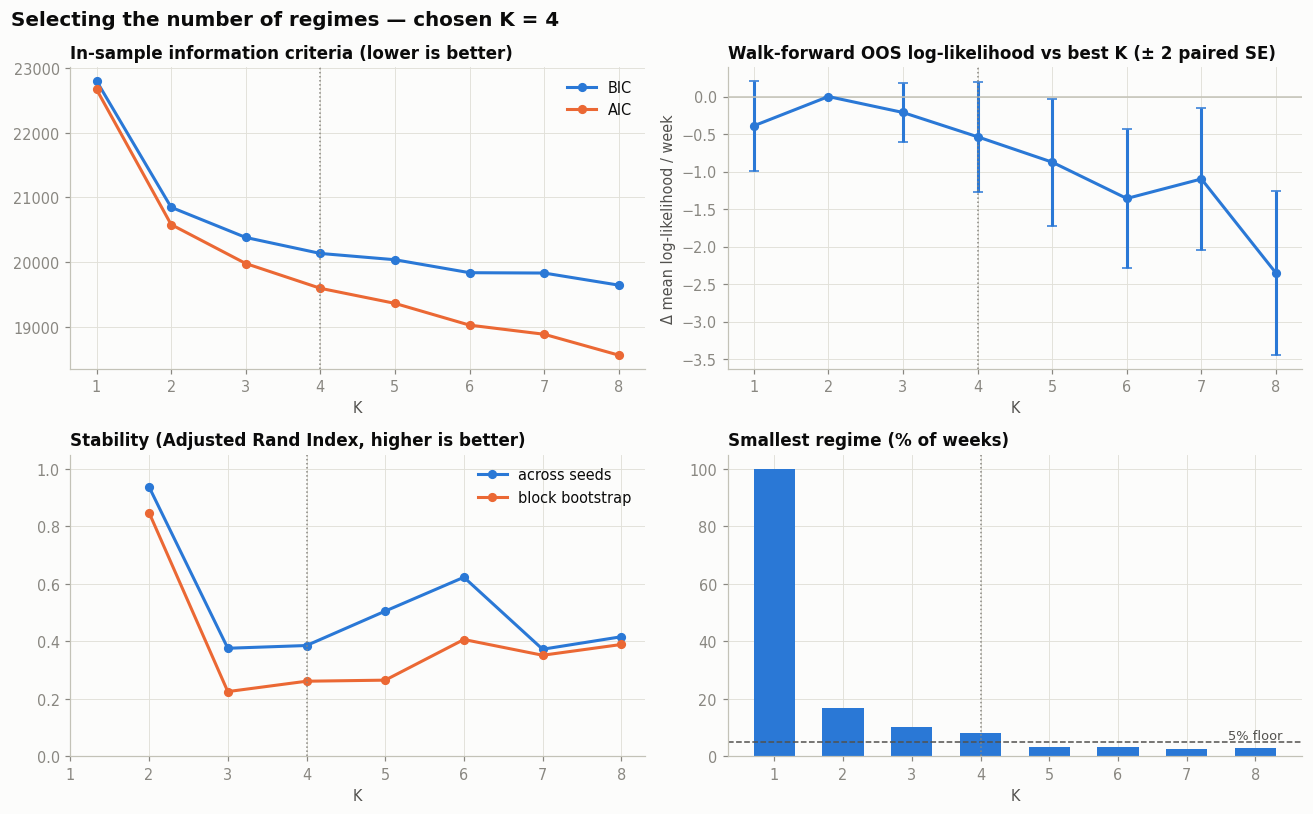

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
ks = list(K_RANGE)

ax = axes[0, 0]
ax.plot(ks, k_diag['BIC'], color=SERIES[0], marker='o', ms=5, label='BIC')
ax.plot(ks, k_diag['AIC'], color=SERIES[1], marker='o', ms=5, label='AIC')
ax.set_title('In-sample information criteria (lower is better)')
ax.legend()

ax = axes[0, 1]
ax.errorbar(ks, k_diag['OOS_LL_gap_vs_best'], yerr=2 * k_diag['OOS_LL_gap_se'], color=SERIES[0],
            marker='o', ms=5, capsize=3, lw=2)
ax.axhline(0, color=AXIS, lw=1)
ax.set_title('Walk-forward OOS log-likelihood vs best K (± 2 paired SE)')
ax.set_ylabel('Δ mean log-likelihood / week')

ax = axes[1, 0]
ax.plot(ks[1:], k_diag.loc[2:, 'ARI_seed'], color=SERIES[0], marker='o', ms=5, label='across seeds')
ax.plot(ks[1:], k_diag.loc[2:, 'ARI_block_boot'], color=SERIES[1], marker='o', ms=5, label='block bootstrap')
ax.set_ylim(0, 1.05)
ax.set_title('Stability (Adjusted Rand Index, higher is better)')
ax.legend()

ax = axes[1, 1]
ax.bar(ks, k_diag['min_share'] * 100, color=SERIES[0], width=0.6)
ax.axhline(MIN_SHARE * 100, color=INK_2, lw=1, ls='--')
ax.text(ks[-1] + 0.4, MIN_SHARE * 100, f'{MIN_SHARE:.0%} floor', va='bottom', ha='right', color=INK_2, fontsize=8.5)
ax.set_title('Smallest regime (% of weeks)')

for ax in axes.flat:
    ax.set_xticks(ks)
    ax.set_xlabel('K')
    ax.axvline(K, color=MUTED, lw=1, ls=':')
fig.suptitle(f'Selecting the number of regimes — chosen K = {K}', x=0.01, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout()
plt.show()

## 5. Walk-forward (point-in-time) regime classification

* The first model is fit on the first 3 years (Aug-2008 → Jul-2011).
* Every 13 weeks the pipeline (scaler, PCA, GMM) is **re-fit on all data available to date** and used to classify the
  following 13 weeks. No label ever comes from a model that has seen that week.
* **Label alignment:** GMM component numbering is arbitrary, so every new fit is matched to the previous fit by
  classifying the new training set with both models and solving the assignment problem (Hungarian algorithm) on the
  agreement matrix. The alignment only uses data up to the re-fit date.

In [8]:
def align_labels(prev_model, prev_perm, new_model, X_ref, k):
    """Permutation mapping raw labels of new_model -> canonical ids (those of prev_model)."""
    prev_lab = prev_perm[prev_model.predict(X_ref)]
    new_lab = new_model.predict(X_ref)
    agree = np.zeros((k, k))
    np.add.at(agree, (new_lab, prev_lab), 1)
    rows_, cols_ = linear_sum_assignment(-agree)
    perm = np.empty(k, dtype=int)
    perm[rows_] = cols_
    return perm, agree[rows_, cols_].sum() / len(X_ref)


def walk_forward(X, k, init_weeks=INIT_WEEKS, refit_every=REFIT_EVERY):
    labels, probs, log = [], [], []
    prev_model, prev_perm = None, None
    for start in range(init_weeks, len(X), refit_every):
        train, test = X.iloc[:start], X.iloc[start:start + refit_every]
        model = make_model(k).fit(train)
        if prev_model is None:
            perm, agreement = np.arange(k), np.nan
        else:
            perm, agreement = align_labels(prev_model, prev_perm, model, train, k)
        raw_p = model.predict_proba(test)
        p = np.zeros_like(raw_p)
        p[:, perm] = raw_p
        probs.append(pd.DataFrame(p, index=test.index))
        labels.append(pd.Series(p.argmax(1), index=test.index))
        log.append({'refit_date': X.index[start - 1].date(), 'train_weeks': len(train), 'agreement_with_prev': agreement})
        prev_model, prev_perm = model, perm
    return pd.concat(labels), pd.concat(probs), pd.DataFrame(log)


labels_pit, probs_pit, refit_log = walk_forward(X, K)
print(f'Out-of-sample labels: {labels_pit.index[0].date()} → {labels_pit.index[-1].date()} '
      f'({len(labels_pit)} weeks, {len(refit_log)} re-fits)')
print(f'Median label agreement between consecutive re-fits on the same training data: '
      f'{refit_log["agreement_with_prev"].median():.1%} (min {refit_log["agreement_with_prev"].min():.1%})')

Out-of-sample labels: 2011-07-29 → 2026-09-28 (793 weeks, 61 re-fits)
Median label agreement between consecutive re-fits on the same training data: 91.9% (min 53.0%)


### Naming the regimes

Names are assigned from the (out-of-sample) regime profiles with simple, reproducible rules:
**Crisis** = highest VIX; **Rate shock** = largest 3m rise in front-end yields (3m bill + 2y); of the rest,
**Calm expansion** = the lowest VIX and the other is **Late cycle / fragile** (see the profile in Section 7 for why).

In [9]:
Xp = X.loc[labels_pit.index]
prof = Xp.groupby(labels_pit).mean()

names = {}
remaining = list(prof.index)
def take(rule_series, name):
    r = rule_series.loc[remaining].idxmax()
    names[r] = name
    remaining.remove(r)

take(prof['log_vix'], 'Crisis')
if K >= 3:
    take(prof['ust_3m_chg_3m'] + prof['ust_2y_chg_3m'], 'Rate shock')
for r, n in zip(prof.loc[remaining, 'log_vix'].sort_values().index, ['Calm expansion', 'Late cycle / fragile']):
    names[r] = n
for r in [r for r in prof.index if r not in names]:
    names[r] = f'Regime {r}'

ORDER = ['Calm expansion', 'Late cycle / fragile', 'Rate shock', 'Crisis']
ORDER = [n for n in ORDER if n in names.values()] + sorted(n for n in names.values() if n not in ORDER)
COLORS = {n: SERIES[i] for i, n in enumerate(ORDER)}

regime = labels_pit.map(names).rename('regime')
probs_named = probs_pit.rename(columns=names)[ORDER]
print(regime.value_counts().reindex(ORDER).to_frame('weeks').assign(share=lambda d: d.weeks / d.weeks.sum()).round(3))

                      weeks  share
regime                            
Calm expansion          461  0.581
Late cycle / fragile    298  0.376
Rate shock               22  0.028
Crisis                   12  0.015


## 6. Regime timeline

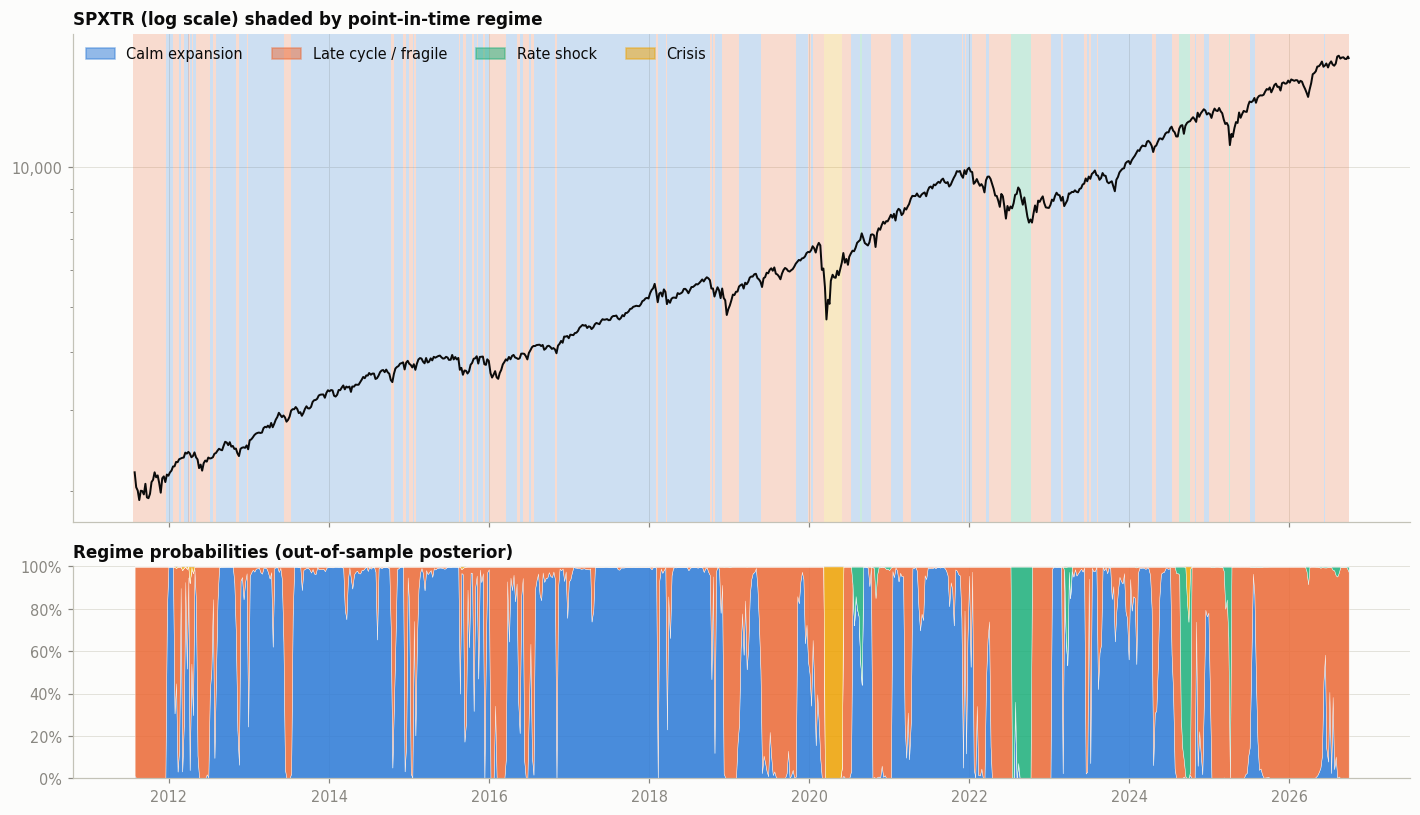

In [10]:
def spans(s):
    """Contiguous (start, end, value) spans of a weekly categorical series."""
    grp = (s != s.shift()).cumsum()
    out = []
    for _, g in s.groupby(grp):
        out.append((g.index[0] - pd.Timedelta(days=6), g.index[-1] + pd.Timedelta(days=1), g.iloc[0]))
    return out


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True, gridspec_kw={'height_ratios': [3, 1.3]})
px_oos = weekly_px.loc[regime.index[0]:]
for a, b, r in spans(regime):
    ax1.axvspan(a, b, color=COLORS[r], alpha=0.22, lw=0)
ax1.plot(px_oos.index, px_oos, color=INK, lw=1.3)
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax1.yaxis.set_minor_formatter(mticker.NullFormatter())
ax1.set_title('SPXTR (log scale) shaded by point-in-time regime')
ax1.legend(handles=[Patch(color=COLORS[n], alpha=0.5, label=n) for n in ORDER], ncol=len(ORDER), loc='upper left')

ax2.stackplot(probs_named.index, probs_named.T.values, colors=[COLORS[n] for n in ORDER], alpha=0.85,
              edgecolor=SURFACE, linewidth=0.3)
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax2.set_title('Regime probabilities (out-of-sample posterior)')
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

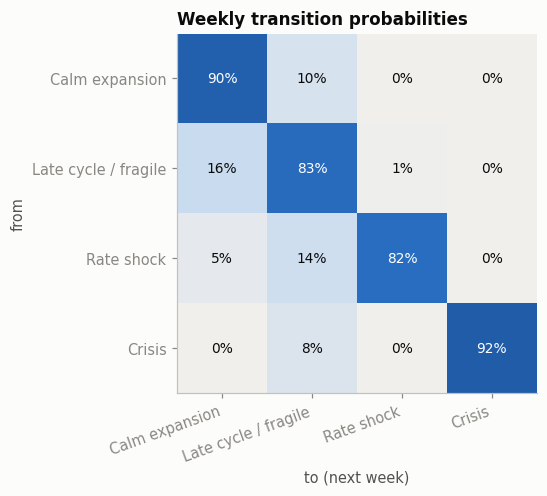

,spells,avg_weeks,max_weeks
regime,,,
Calm expansion,48,9.6,65.0
Late cycle / fragile,52,5.7,45.0
Rate shock,4,5.5,13.0
Crisis,1,12.0,12.0


In [11]:
# Regime persistence: weekly transition matrix and spell lengths
trans = pd.crosstab(regime.shift().rename('from'), regime.rename('to'), normalize='index').reindex(index=ORDER, columns=ORDER)
spell = pd.DataFrame([(r, (b - a).days / 7) for a, b, r in spans(regime)], columns=['regime', 'weeks'])
spell_stats = spell.groupby('regime')['weeks'].agg(spells='count', avg_weeks='mean', max_weeks='max').reindex(ORDER)

fig, ax = plt.subplots(figsize=(6.2, 4.6))
im = ax.imshow(trans.values, cmap=SEQUENTIAL, vmin=0, vmax=1)
for i in range(len(ORDER)):
    for j in range(len(ORDER)):
        v = trans.values[i, j]
        ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=9, color='white' if v > 0.6 else INK)
ax.set_xticks(range(len(ORDER)), ORDER, rotation=20, ha='right')
ax.set_yticks(range(len(ORDER)), ORDER)
ax.set_xlabel('to (next week)')
ax.set_ylabel('from')
ax.grid(False)
ax.set_title('Weekly transition probabilities')
fig.tight_layout()
plt.show()
spell_stats.round(1)

In [12]:
# Every spell of the rare regimes (dates = first / last classified week)
grp = (regime != regime.shift()).cumsum()
episodes = (regime.to_frame().assign(date=regime.index).groupby(grp)
            .agg(regime=('regime', 'first'), start=('date', 'first'), end=('date', 'last'), weeks=('date', 'size')))
episodes[episodes.regime.isin(['Rate shock', 'Crisis'])].reset_index(drop=True)

,regime,start,end,weeks
0,Crisis,2020-03-13,2020-05-29,12
1,Rate shock,2020-08-28,2020-08-28,1
2,Rate shock,2022-07-15,2022-10-07,13
3,Rate shock,2024-08-23,2024-10-04,7
4,Rate shock,2025-04-04,2025-04-04,1


## 7. Economic profile of each regime

Mean and standard deviation of every variable within each (out-of-sample) regime. Two views:

* **Model features** (what the GMM saw), and
* **Raw levels of every series in the file** — including the short-history series that could not be model inputs
  (`tlt_vol_bp`, `wti`, `vixeq`, `tips_30y`; their statistics use only the weeks where they exist — see `n`).

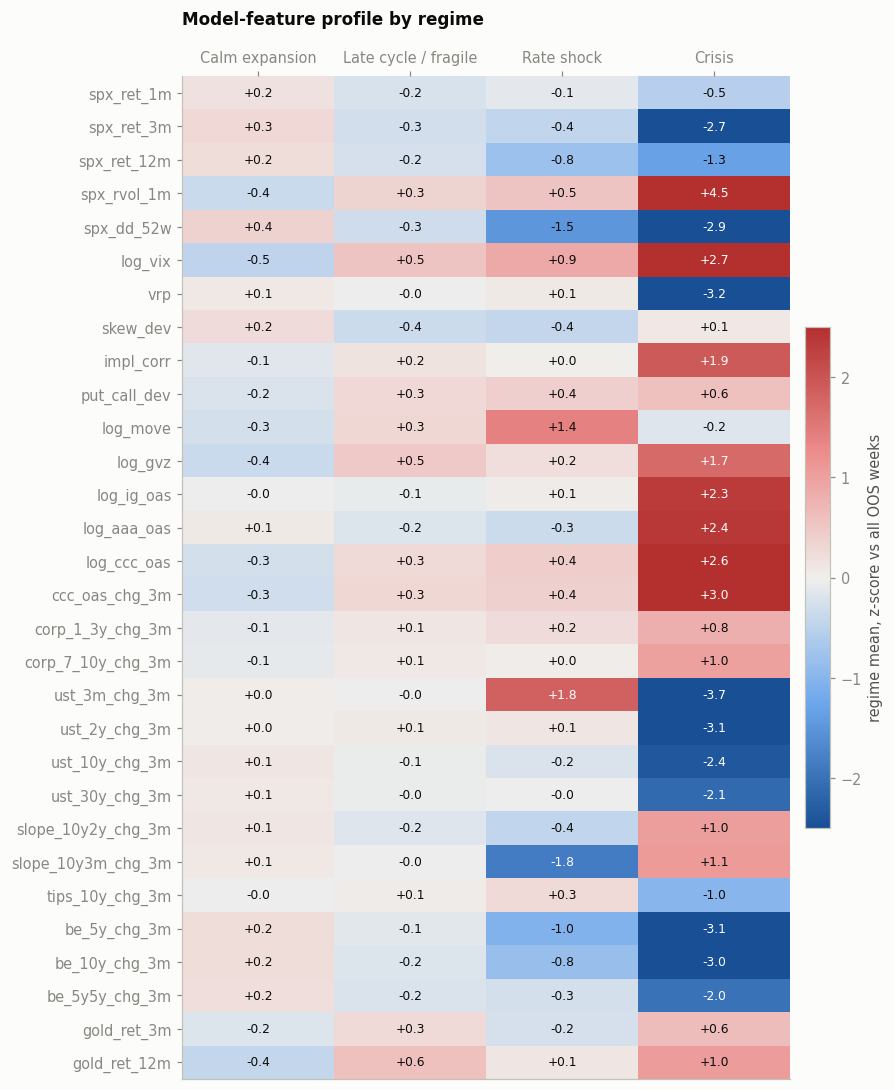

In [13]:
feat_stats = Xp.groupby(regime).agg(['mean', 'std']).T.unstack(level=1)
feat_stats = feat_stats.reindex(columns=pd.MultiIndex.from_product([ORDER, ['mean', 'std']]))

# heatmap: regime means standardised by the (OOS-period) cross-regime S.D. of each feature — display only
z = (prof.rename(index=names).reindex(ORDER) - Xp.mean()) / Xp.std()
fig, ax = plt.subplots(figsize=(8.5, 10))
im = ax.imshow(z.T.values, cmap=DIVERGING, vmin=-2.5, vmax=2.5, aspect='auto')
for i in range(z.shape[1]):
    for j in range(z.shape[0]):
        v = z.values[j, i]
        ax.text(j, i, f'{v:+.1f}', ha='center', va='center', fontsize=8, color='white' if abs(v) > 1.6 else INK)
ax.set_xticks(range(len(ORDER)), ORDER)
ax.xaxis.tick_top()
ax.set_yticks(range(len(FEATURES)), FEATURES)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.02)
cb.set_label('regime mean, z-score vs all OOS weeks')
ax.set_title('Model-feature profile by regime', pad=34)
fig.tight_layout()
plt.show()

In [14]:
pd.options.display.float_format = '{:,.3f}'.format
feat_stats

Calm expansion        Late cycle / fragile        Rate shock        Crisis      
                             mean    std                 mean    std       mean    std   mean   std
spx_ret_1m                  0.019  0.028                0.003  0.048      0.008  0.070 -0.011 0.160
spx_ret_3m                  0.054  0.045                0.018  0.072      0.008  0.074 -0.140 0.078
spx_ret_12m                 0.178  0.104                0.120  0.133      0.051  0.193 -0.015 0.079
spx_rvol_1m                 0.113  0.044                0.179  0.084      0.197  0.054  0.568 0.290
spx_dd_52w                 -0.018  0.025               -0.051  0.054     -0.109  0.086 -0.181 0.065
log_vix                     2.685  0.230                3.002  0.282      3.114  0.266  3.691 0.319
vrp                         0.038  0.034                0.031  0.060      0.036  0.046 -0.148 0.191
skew_dev                    3.171  8.713               -2.448  9.240     -3.007 13.557  1.725 5.307
impl_corr                  30.574 12.437               35.703 21.261     33.219 14.389 65.738 7.747
put_call_dev               -0.029  0.096                0.026  0.123      0.039  0.122  0.062 0.146
log_move                    4.227  0.288                4.397  0.272      4.726  0.233  4.256 0.351
log_gvz                     2.716  0.236                2.956  0.278      2.875  0.110  3.303 0.238
log_ig_oas                  0.222  0.211                0.208  0.359      0.243  0.223  0.900 0.205
log_aaa_oas                -0.518  0.217               -0.590  0.351     -0.639  0.268  0.151 0.221
log_ccc_oas                 2.184  0.215                2.310  0.223      2.344  0.136  2.857 0.059
ccc_oas_chg_3m             -0.050  0.128                0.058  0.190      0.071  0.184  0.542 0.092
corp_1_3y_chg_3m            0.007  0.341                0.107  0.594      0.170  0.863  0.446 0.756
corp_7_10y_chg_3m          -0.018  0.404                0.063  0.538      0.037  0.558  0.482 0.482
ust_3m_chg_3m               0.071  0.175                0.052  0.415      0.792  1.036 -1.406 0.118
ust_2y_chg_3m               0.084  0.264                0.093  0.486      0.110  0.903 -1.215 0.175
ust_10y_chg_3m              0.077  0.329                0.007  0.487     -0.052  0.486 -0.964 0.216
ust_30y_chg_3m              0.053  0.317                0.006  0.447      0.012  0.357 -0.786 0.246
slope_10y2y_chg_3m         -0.007  0.255               -0.086  0.291     -0.162  0.488  0.251 0.081
slope_10y3m_chg_3m          0.006  0.369               -0.045  0.453     -0.845  0.749  0.442 0.169
tips_10y_chg_3m             0.025  0.290                0.050  0.415      0.126  0.507 -0.314 0.270
be_5y_chg_3m                0.071  0.250               -0.036  0.297     -0.314  0.335 -0.941 0.208
be_10y_chg_3m               0.051  0.188               -0.042  0.221     -0.186  0.230 -0.667 0.221
be_5y5y_chg_3m              0.032  0.174               -0.048  0.203     -0.059  0.157 -0.394 0.243
gold_ret_3m                 0.003  0.065                0.038  0.092     -0.002  0.097  0.066 0.026
gold_ret_12m                0.007  0.128                0.178  0.174      0.098  0.170  0.255 0.056

In [15]:
# Raw levels of every series in the file (sampled weekly, point-in-time daily frame)
lv = daily.resample('W-FRI').last().set_axis(weekly.index)
levels = pd.DataFrame(index=lv.index)
levels['SPXTR 12m return (%)'] = F['spx_ret_12m'].resample('W-FRI').last().values * 100
levels['SPXTR 1m realised vol (%)'] = F['spx_rvol_1m'].resample('W-FRI').last().values * 100
levels['SPXTR drawdown from 52w high (%)'] = F['spx_dd_52w'].resample('W-FRI').last().values * 100
levels['VIX'] = lv['vix']
levels['VIXEQ (constituent vol)'] = lv['vixeq']
levels['Implied correlation (1m)'] = lv['impl_corr']
levels['SKEW'] = lv['skew']
levels['Equity put/call'] = lv['put_call']
levels['MOVE (bond vol)'] = lv['move']
levels['TLT vol (bp)'] = lv['tlt_vol_bp']
levels['GVZ (gold vol)'] = lv['gvz']
levels['IG OAS (bp)'] = lv['ig_oas'] * 100
levels['AAA OAS (bp)'] = lv['aaa_oas'] * 100
levels['CCC OAS (bp)'] = lv['ccc_oas'] * 100
levels['Corp 1-3y yield (%)'] = lv['corp_1_3y']
levels['Corp 7-10y yield (%)'] = lv['corp_7_10y']
levels['UST 3m (%)'] = lv['ust_3m']
levels['UST 2y (%)'] = lv['ust_2y']
levels['UST 10y (%)'] = lv['ust_10y']
levels['UST 30y (%)'] = lv['ust_30y']
levels['10y-2y slope (bp)'] = (lv['ust_10y'] - lv['ust_2y']) * 100
levels['10y-3m slope (bp)'] = (lv['ust_10y'] - lv['ust_3m']) * 100
levels['UST 2y 3m change (bp)'] = X['ust_2y_chg_3m'].reindex(lv.index) * 100
levels['10y TIPS real yield (%)'] = lv['tips_10y']
levels['30y TIPS real yield (%)'] = lv['tips_30y']
levels['5y breakeven (%)'] = lv['be_5y']
levels['10y breakeven (%)'] = lv['be_10y']
levels['5y5y fwd inflation (%)'] = lv['be_5y5y']
levels['Real policy rate: 3m − 5y BE (%)'] = lv['ust_3m'] - lv['be_5y']
levels['Gold 12m return (%)'] = (lv['gold'] / lv['gold'].shift(52) - 1) * 100
levels['WTI crude ($)'] = lv['wti']
levels['WTI 3m return (%)'] = (lv['wti'] / lv['wti'].shift(13) - 1) * 100
levels = levels.loc[regime.index]

level_stats = levels.groupby(regime).agg(['mean', 'std', 'count']).T.unstack(level=1)
level_stats = level_stats.reindex(columns=pd.MultiIndex.from_product([ORDER, ['mean', 'std', 'count']]))
level_stats = level_stats.rename(columns={'std': 'sd', 'count': 'n'}, level=1)
level_stats.style.format('{:,.2f}').format('{:,.0f}', subset=pd.IndexSlice[:, pd.IndexSlice[:, 'n']])

## 8. Forward SPXTR returns by regime (out-of-sample)

For every week classified point-in-time, the forward SPXTR return from that week's close. Statistics per regime:
mean, median, S.D., hit rate (% positive), mean return annualised, and a **Newey-West (HAC) t-stat of the difference
vs. all other weeks** (lags = horizon, because overlapping forward windows are autocorrelated). `episodes` = number of
distinct regime spells — the effective number of independent observations is closer to this than to `weeks`.

In [16]:
fwd_oos = fwd.loc[regime.index]


def hac_tstat(y, dummy, lags):
    m = y.notna()
    res = sm.OLS(y[m], sm.add_constant(dummy[m].astype(float))).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return res.tvalues.iloc[1]


rows = []
for h, n in HORIZONS.items():
    y = fwd_oos[h]
    for r in ORDER + ['All weeks']:
        sel = y if r == 'All weeks' else y[regime == r]
        sel = sel.dropna()
        rows.append({
            'horizon': h, 'regime': r, 'weeks': len(sel),
            'episodes': len(spell[spell.regime == r]) if r != 'All weeks' else np.nan,
            'mean': sel.mean(), 'median': sel.median(), 'std': sel.std(),
            'hit_rate': (sel > 0).mean(), 'p10': sel.quantile(0.1), 'p90': sel.quantile(0.9),
            'mean_annualised': (1 + sel.mean()) ** (52 / n) - 1,
            't_vs_rest (HAC)': hac_tstat(y, regime == r, n) if r != 'All weeks' else np.nan,
        })
fwd_table = pd.DataFrame(rows).set_index(['horizon', 'regime'])
fwd_table.style.format({
    'weeks': '{:.0f}', 'episodes': '{:.0f}', 'mean': '{:.2%}', 'median': '{:.2%}', 'std': '{:.2%}',
    'hit_rate': '{:.0%}', 'p10': '{:.1%}', 'p90': '{:.1%}', 'mean_annualised': '{:.1%}', 't_vs_rest (HAC)': '{:+.2f}',
}, na_rep='')

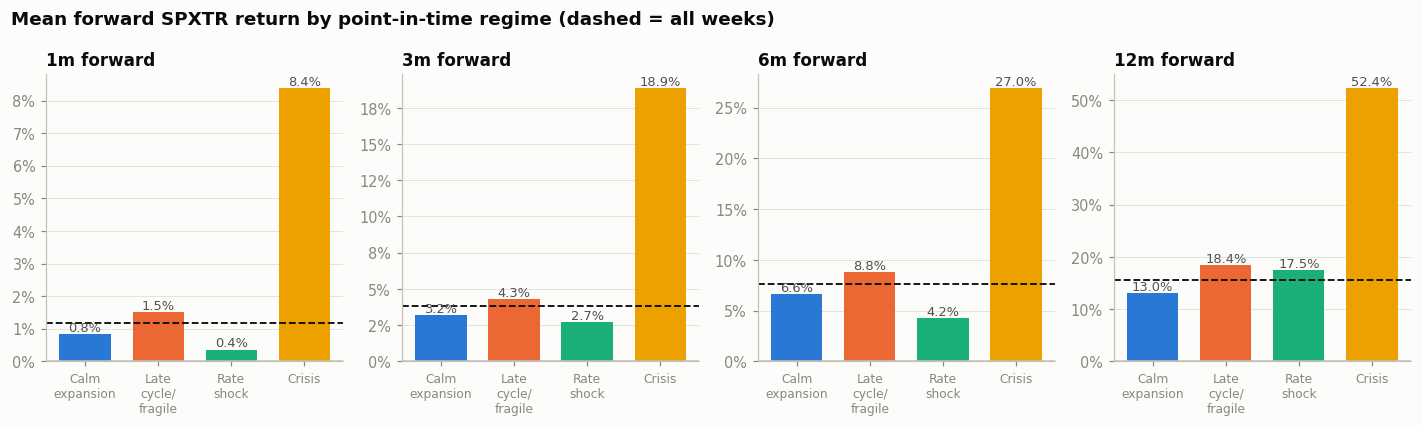

In [17]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(13, 3.9))
for ax, h in zip(axes, HORIZONS):
    vals = [fwd_table.loc[(h, r), 'mean'] * 100 for r in ORDER]
    ax.bar(range(len(ORDER)), vals, color=[COLORS[r] for r in ORDER], width=0.7)
    ax.axhline(fwd_table.loc[(h, 'All weeks'), 'mean'] * 100, color=INK, lw=1.2, ls='--')
    ax.axhline(0, color=AXIS, lw=1)
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8.5, color=INK_2)
    ax.set_xticks(range(len(ORDER)), [r.replace(' / ', '/\n').replace(' ', '\n') for r in ORDER], fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.set_title(f'{h} forward')
    ax.grid(axis='x', visible=False)
fig.suptitle('Mean forward SPXTR return by point-in-time regime (dashed = all weeks)', x=0.01, ha='left',
             fontsize=12, fontweight='semibold')
fig.tight_layout()
plt.show()

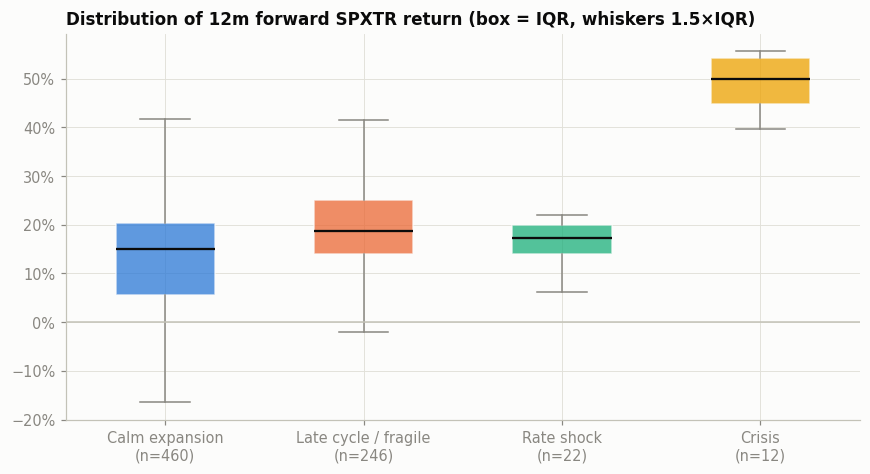

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.4))
data12 = [fwd_oos.loc[regime == r, '12m'].dropna() * 100 for r in ORDER]
bp = ax.boxplot(data12, widths=0.5, patch_artist=True, showfliers=False,
                medianprops={'color': INK, 'lw': 1.5}, whiskerprops={'color': MUTED}, capprops={'color': MUTED})
for patch, r in zip(bp['boxes'], ORDER):
    patch.set_facecolor(COLORS[r]); patch.set_alpha(0.75); patch.set_edgecolor(SURFACE)
ax.axhline(0, color=AXIS, lw=1)
ax.set_xticks(range(1, len(ORDER) + 1), [f'{r}\n(n={len(d)})' for r, d in zip(ORDER, data12)])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_title('Distribution of 12m forward SPXTR return (box = IQR, whiskers 1.5×IQR)')
fig.tight_layout()
plt.show()

## 9. Robustness

**(a) How much does look-ahead flatter the result?** The same pipeline fit **once on the full sample** (every label
is informed by the future) — shown only as a contrast, *not* as a result.

**(b) Sensitivity to K.** Point-in-time forward returns for K−1 and K+1: are the conclusions an artefact of K?

In [19]:
full_model = make_model(K).fit(X)
lab_full = pd.Series(full_model.predict(X), index=X.index)
# map full-sample labels to PIT names by maximum overlap over the OOS period
agree = pd.crosstab(lab_full.loc[regime.index], regime).reindex(columns=ORDER, fill_value=0)
r_, c_ = linear_sum_assignment(-agree.values)
full_names = {agree.index[i]: ORDER[j] for i, j in zip(r_, c_)}
regime_full = lab_full.map(full_names)
print(f'Agreement of full-sample (look-ahead) labels with point-in-time labels over the OOS period: '
      f'{(regime_full.loc[regime.index] == regime).mean():.1%}')

cmp = pd.concat({
    'point-in-time (OOS)': fwd_oos.groupby(regime).mean(),
    'full-sample fit, same weeks (look-ahead)': fwd.loc[regime.index].groupby(regime_full.loc[regime.index]).mean(),
    'full-sample fit, 2008-2026 (look-ahead)': fwd.groupby(regime_full).mean(),
}, axis=1).reindex(ORDER)
cmp.style.format('{:.2%}')

Agreement of full-sample (look-ahead) labels with point-in-time labels over the OOS period: 66.8%


In [20]:
sens = {}
for k_alt in sorted({2, K - 1, K + 1} - {K, 1}):
    lab_alt, _, _ = walk_forward(X, k_alt)
    g = fwd.loc[lab_alt.index].groupby(lab_alt)
    t = g.mean().join(g.size().rename('weeks'))
    t['avg VIX'] = levels['VIX'].reindex(lab_alt.index).groupby(lab_alt).mean()
    t['avg IG OAS (bp)'] = levels['IG OAS (bp)'].reindex(lab_alt.index).groupby(lab_alt).mean()
    t['avg Δ3m UST 2y (bp)'] = levels['UST 2y 3m change (bp)'].reindex(lab_alt.index).groupby(lab_alt).mean()
    sens[f'K={k_alt}'] = t.sort_values('avg VIX')
sens_df = pd.concat(sens)
sens_df.style.format({**{h: '{:.2%}' for h in HORIZONS}, 'weeks': '{:.0f}', 'avg VIX': '{:.1f}',
                      'avg IG OAS (bp)': '{:.0f}', 'avg Δ3m UST 2y (bp)': '{:+.0f}'})

In [21]:
# Current regime (latest point-in-time classification)
latest = probs_named.iloc[-1]
print(f'Latest week: {probs_named.index[-1].date()}  →  {regime.iloc[-1]}')
latest.to_frame('probability').style.format('{:.1%}')

Latest week: 2026-09-28  →  Late cycle / fragile


,probability
Calm expansion,0.0%
Late cycle / fragile,97.4%
Rate shock,2.6%
Crisis,0.0%


## 10. Conclusions (data through 28-Sep-2026; out-of-sample labels Jul-2011 → Sep-2026)

**Choice of K = 4.** Walk-forward out-of-sample likelihood cannot statistically separate K = 2, 3 and 4 (gaps vs. the
best K are within ~1.5 paired S.E.), whereas K ≥ 5 is significantly worse out-of-sample *and* creates regimes that
cover < 5% of weeks (too thin to estimate forward returns). K = 4 is the richest model the data supports, and each
of its regimes has a clear macro reading. Caveat: seed/bootstrap ARI for K ≥ 3 is only ~0.3–0.4 — the boundary
between the two "normal" regimes is soft, so the posterior probabilities are more informative than the hard label.

**Economic profile of the regimes (point-in-time)**

| Regime | Share | What characterises it |
|---|---|---|
| **Calm expansion** | 58% | VIX ≈ 15, realised vol ≈ 11%, drawdown ≈ −2%; steep curve (10y-2y ≈ +95 bp); negative real policy rate (≈ −0.6%); rising breakevens; gold flat; strong trailing SPXTR (+18% 12m) |
| **Late cycle / fragile** | 38% | VIX ≈ 21, realised vol ≈ 18%, drawdown ≈ −5%; flatter curve (≈ +63 bp); real policy rate ≈ 0 and higher front-end yields; wider CCC spreads; gold bid (+21% 12m, higher GVZ); weaker trailing SPXTR (+12%) |
| **Rate shock** | 3% | Front-end yields jump (3m bill ≈ +80 bp in 3m), inverted curve, MOVE ≈ 115, real policy rate ≈ +1.1%, falling breakevens and oil; SPXTR ≈ −11% from high. Episodes: Jul–Oct 2022, Aug–Oct 2024 (yen-carry unwind) |
| **Crisis** | 1.5% | VIX ≈ 42, realised vol ≈ 57%, implied correlation ≈ 63, IG OAS ≈ 250 bp / CCC ≈ 1,740 bp, yields and breakevens collapse, WTI −51%. Out-of-sample this is only COVID (Mar–May 2020) |

**Forward SPXTR returns (point-in-time, all weeks: +15.6% over 12m)**

* **Calm expansion → below-average returns** (12m +13.0%, HAC t = −2.4). Low vol and tight conditions are already
  priced; this is the only result that is statistically significant with a large number of independent episodes (48 spells).
* **Late cycle / fragile → above-average returns** (12m +18.4%, t = +1.8; 93% hit rate, 10th percentile still +5%).
  Elevated-but-not-extreme risk is compensated — a risk-premium effect, not a sell signal.
* **Rate shock → weak near term** (6m +4.2% vs +7.7%, t = −1.7), normal over 12m (+17.5%). Only 4 spells (22 weeks).
* **Crisis → very strong subsequent returns** (12m +52%), but this is **a single episode** (COVID rebound) and cannot be
  generalised; the full-sample fit including the GFC entry shows a far more modest +28% 12m.
* The pattern is robust to K: at K = 2 and K = 3 the higher-stress regime also has the higher forward return and the
  calmest regime is below average.

**Why point-in-time matters here.** A single full-sample fit agrees with the point-in-time labels on only ~67% of
weeks: hindsight relabels a third of history. In particular the point-in-time model could not recognise the 2022
hiking cycle as a "rate shock" until mid-2022, because nothing similar existed in its 2008-2021 training data — an
unavoidable limitation of any honest regime model.

**Current state.** The latest week (28-Sep-2026) is classified **Late cycle / fragile** with ~97% probability.